In [ ]:
# Import Pandas to manipulate data as tables (DataFrames)
import pandas as pd
# Import Numpy for heavy mathematical operations and arrays
import numpy as np
# Import Matplotlib for drawing graphs and visual plots
import matplotlib.pyplot as plt
# Import TensorFlow, the core deep learning engine
import tensorflow as tf
# Import a tool to split our dataset into training and testing parts
from sklearn.model_selection import train_test_split
# Import a tool to scale our data so all features have equal weight
from sklearn.preprocessing import StandardScaler
# Import tools to generate the final grading reports and confusion matrix graph
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
# Import Sequential to build our neural network layer-by-layer
from keras.models import Sequential
# Import Dense to create standard, fully-connected neural network layers
from keras.layers import Dense
# Import Adam, the optimizer algorithm that helps the model learn efficiently
from tensorflow.keras.optimizers import Adam
# Import display to show our final results table neatly in the notebook
from IPython.display import display
# Import warnings to hide annoying update messages from Python
import warnings
# Tell Python to ignore and hide all simple warning messages
warnings.simplefilter('ignore')

# Print the current TensorFlow version to confirm it is installed correctly
print("TensorFlow version:", tf.__version__)

# Download the red wine dataset directly from the internet using pandas
red = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=';')
# Download the white wine dataset directly from the internet using pandas
white = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv", sep=';')

# Create a new column called 'type' and set it to 1 for all red wine rows
red['type'] = 1 
# Create a new column called 'type' and set it to 0 for all white wine rows
white['type'] = 0 

# Glue the red and white tables together vertically, resetting the row numbers
wines = pd.concat([red, white], ignore_index=True)
# Remove any rows that contain missing or NULL values to keep the data clean
wines.dropna(inplace=True)
# Print a success message showing the total number of rows loaded
print("Data loaded Total rows:", len(wines))

TensorFlow version: 2.21.0
 Data  loaded Total rows: 6497


In [ ]:
# Grab all rows, and all columns EXCEPT the last one (the 12 chemical features)
X = wines.iloc[:, :-1]
# Grab only the 'type' column (the 1s and 0s we want to predict)
y = wines['type']

# Initialize the StandardScaler tool to equalize the numbers
scaler = StandardScaler()
# Apply the scaler to our features (X) so large numbers don't overpower small ones
X_scaled = scaler.fit_transform(X)

# Split data: 66% for training, 34% for testing. 'random_state=45' guarantees the exact same shuffle every time
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.34, random_state=45)
# Print a success message confirming the data is ready for the model
print("Data successfully scaled and split.")

Data successfully scaled and split


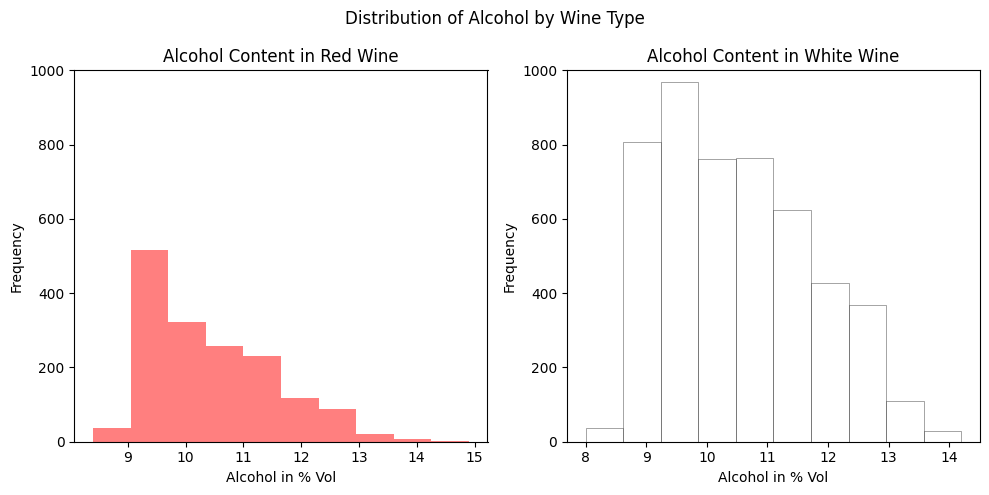

In [ ]:
# Create a drawing window (fig) containing 1 row and 2 columns of graphs (ax), sized 10x5 inches
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# On the left graph (ax[0]), draw a red histogram of alcohol content for Red wine (type == 1)
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
# On the right graph (ax[1]), draw a white histogram (with black borders) for White wine (type == 0)
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

# Loop through both graphs (left and right) to apply the same formatting rules
for a in ax:
    # Lock the Y-axis so both graphs max out at exactly 1000 for a fair comparison
    a.set_ylim([0, 1000])
    # Add a text label to the X-axis of both graphs
    a.set_xlabel('Alcohol in % Vol')
    # Add a text label to the Y-axis of both graphs
    a.set_ylabel('Frequency')

# Add a specific title to the top of the left graph
ax[0].set_title('Alcohol Content in Red Wine')
# Add a specific title to the top of the right graph
ax[1].set_title('Alcohol Content in White Wine')

# Add a giant master title hovering over the entire window
fig.suptitle('Distribution of Alcohol by Wine Type')
# Automatically adjust the spacing so titles and graphs don't overlap
plt.tight_layout()
# Render and display the final drawn graphic on the screen
plt.show()

In [ ]:
# Print a simple header text
print("--- RUNNING WARM-UP TEST ---")

# Initialize a new, empty sequential neural network (data flows left to right)
test_model = Sequential()
# Add the first hidden layer: 12 nodes, ReLU activation, expecting 12 chemical inputs
test_model.add(Dense(12, activation='relu', input_dim=12))
# Add a second hidden layer: 9 nodes, ReLU activation (filters out negative noise)
test_model.add(Dense(9, activation='relu'))
# Add the final output layer: 1 node, Sigmoid activation (forces output to be a probability between 0 and 1)
test_model.add(Dense(1, activation='sigmoid'))

# Set the rules: use binary loss calculation, Adam optimizer, and track accuracy percentage
test_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train the model on the training data for exactly 3 rounds (epochs), processing 32 rows at a time
test_model.fit(X_train, y_train, epochs=3, batch_size=32, verbose=1)

# Print a header for the predictions
print("\n--- TEST PREDICTIONS ---")
# Ask the trained model to predict the probabilities for only the first 12 test rows
y_pred_probs = test_model.predict(X_test[:12]) 
# Convert any probability >= 0.5 into a solid '1', and anything lower into a '0'
y_pred_labels = (y_pred_probs >= 0.5).astype(int)

# Loop through those 12 hard predictions one by one
for prediction in y_pred_labels:
    # If the prediction is 1, call it "Red wine", otherwise call it "White wine"
    wine_type = "Red wine" if prediction == 1 else "White wine"
    # Print the human-readable result to the screen
    print(f"Prediction: {wine_type}")

--- RUNNING WARM-UP TEST ---
Epoch 1/3
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.5326 - loss: 0.6932
Epoch 2/3
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - accuracy: 0.9370 - loss: 0.3286
Epoch 3/3
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.9783 - loss: 0.1193

--- TEST PREDICTIONS ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: Red wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine


In [ ]:
# Create a list of dictionaries, where each dictionary is a blueprint for a different model setup
experiments = [
    {'id': 1, 'layers': 2, 'nodes': [12, 9], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Baseline'},
    {'id': 2, 'layers': 2, 'nodes': [12, 9], 'epochs': 50, 'batch': 32, 'lr': 0.001, 'note': 'More Epochs'},
    {'id': 3, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Wider Network'},
    {'id': 4, 'layers': 2, 'nodes': [32, 16], 'epochs': 50, 'batch': 32, 'lr': 0.001, 'note': 'Wider + More Epochs'},
    {'id': 5, 'layers': 3, 'nodes': [64, 32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Deeper Network (3)'},
    {'id': 6, 'layers': 1, 'nodes': [16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Shallow Network (1)'},
    {'id': 7, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.01, 'note': 'High Learning Rate'},
    {'id': 8, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.0001, 'note': 'Low Learning Rate'},
    {'id': 9, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 128, 'lr': 0.001, 'note': 'Larger Batch Size'},
    {'id': 10, 'layers': 3, 'nodes': [64, 64, 32], 'epochs': 100, 'batch': 32, 'lr': 0.001, 'note': 'Max Power'}
]

# Create an empty list to store the final accuracy scores
results = []
# Print a starting message
print("Starting 10 Experiments...\n")

# Loop through every single blueprint dictionary inside the 'experiments' list
for exp in experiments:
    
    # Initialize a fresh, empty neural network for this specific experiment
    model = Sequential()
    
    # Loop based on how many hidden layers this experiment asks for
    for i in range(exp['layers']):
        # If it's the very first layer (index 0), we must include the input_dim=12
        if i == 0:
            model.add(Dense(exp['nodes'][i], activation='relu', input_dim=12))
        # For all subsequent layers, we just add the nodes without input_dim
        else:
            model.add(Dense(exp['nodes'][i], activation='relu'))
            
    # Add the standard final output layer for binary classification (1 node, sigmoid)
    model.add(Dense(1, activation='sigmoid')) 
    
    # Compile the model using the specific learning rate ('lr') requested by the blueprint
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=exp['lr']), metrics=['accuracy'])
    
    # Train the model using the specific epochs and batch size from the blueprint. verbose=0 hides loading bars.
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)
    
    # Test the trained model against the hidden test data. Returns loss and accuracy variables.
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Save the experiment's details and its final accuracy score into our 'results' bucket
    results.append({
        'Experiment ID': exp['id'],
        'Description': exp['note'],
        'Epochs': exp['epochs'],
        'Accuracy': round(accuracy, 4)
    })
    
    # Print a single-line confirmation message that this specific experiment finished
    print(f"Exp {exp['id']} done! ({exp['note']}) -> Accuracy: {accuracy*100:.2f}%")

# Convert our list of results into a clean Pandas table (DataFrame)
df_results = pd.DataFrame(results)
# Save the table to the hard drive as a CSV file, separated by semicolons
df_results.to_csv('DeepLearning_Experiment_Results.csv', index=False, sep=';')
# Print a completion message
print("\nEXPERIMENTS COMPLETED.")
# Render the final results table beautifully inside the notebook
display(df_results)

Starting 10 Experiments...

✅ Exp 1 done! (Baseline) -> Accuracy: 99.14%
✅ Exp 2 done! (More Epochs) -> Accuracy: 99.46%
✅ Exp 3 done! (Wider Network) -> Accuracy: 99.46%
✅ Exp 4 done! (Wider + More Epochs) -> Accuracy: 99.41%
✅ Exp 5 done! (Deeper Network (3)) -> Accuracy: 99.46%
✅ Exp 6 done! (Shallow Network (1)) -> Accuracy: 99.46%
✅ Exp 7 done! (High Learning Rate) -> Accuracy: 99.50%
✅ Exp 8 done! (Low Learning Rate) -> Accuracy: 99.19%
✅ Exp 9 done! (Larger Batch Size) -> Accuracy: 99.28%
✅ Exp 10 done! (Max Power) -> Accuracy: 99.37%

EXPERIMENTS COMPLETED.


,Experiment ID,Description,Epochs,Accuracy
0,1,Baseline,10,0.9914
1,2,More Epochs,50,0.9946
2,3,Wider Network,20,0.9946
3,4,Wider + More Epochs,50,0.9941
4,5,Deeper Network (3),20,0.9946
5,6,Shallow Network (1),20,0.9946
6,7,High Learning Rate,20,0.9950
7,8,Low Learning Rate,20,0.9919
8,9,Larger Batch Size,20,0.9928
9,10,Max Power,100,0.9937


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

--- FINAL CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

White Wine (0)       0.99      1.00      1.00      1641
  Red Wine (1)       0.99      0.98      0.99       568

      accuracy                           0.99      2209
     macro avg       0.99      0.99      0.99      2209
  weighted avg       0.99      0.99      0.99      2209



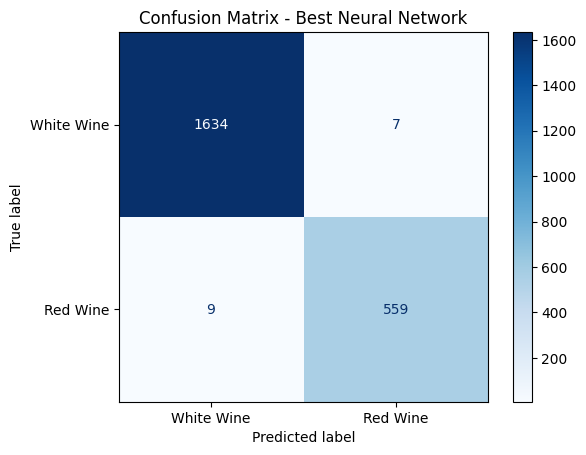

In [ ]:
# Initialize our absolute best, champion model found in the experiments
final_model = Sequential()
# Add the first hidden layer with 64 nodes and 12 inputs
final_model.add(Dense(64, activation='relu', input_dim=12))
# Add the second hidden layer with 64 nodes
final_model.add(Dense(64, activation='relu'))
# Add the third hidden layer with 32 nodes
final_model.add(Dense(32, activation='relu'))
# Add the final output layer (1 node, sigmoid)
final_model.add(Dense(1, activation='sigmoid'))

# Compile the champion model with our best learning rate of 0.001
final_model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
# Train the champion model for 100 epochs, hiding the loading bar (verbose=0)
final_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

# Ask the champion model to predict probabilities for the hidden test data
y_pred_probs = final_model.predict(X_test)
# Convert those probabilities into hard 1 (Red) or 0 (White) answers
y_pred_labels = (y_pred_probs >= 0.5).astype(int)

# Print a header for the classification report
print("\n--- FINAL CLASSIFICATION REPORT ---")
# Generate and print the detailed report card showing Precision and Recall for both wines
print(classification_report(y_test, y_pred_labels, target_names=['White Wine (0)', 'Red Wine (1)']))

# Draw the 2x2 visual grid comparing true answers (y_test) to guesses (y_pred_labels), colored blue
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_labels, cmap='Blues', display_labels=['White Wine', 'Red Wine'])
# Add a title to the top of the confusion matrix graph
plt.title("Confusion Matrix - Best Neural Network")
# Render and display the final graph to the screen
plt.show()